In [ ]:
!pip install xgboost shap joblib

In [ ]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
print(model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# ML

from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving European_Bank.csv to European_Bank.csv


In [ ]:
df = pd.read_csv(
    "European_Bank.csv"
)


df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
print(df.columns.tolist())

['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
df.drop(
    [
        "RowNumber",
        "CustomerId",
        "Surname"
    ],
    axis=1,
    inplace=True,
    errors='ignore'
)

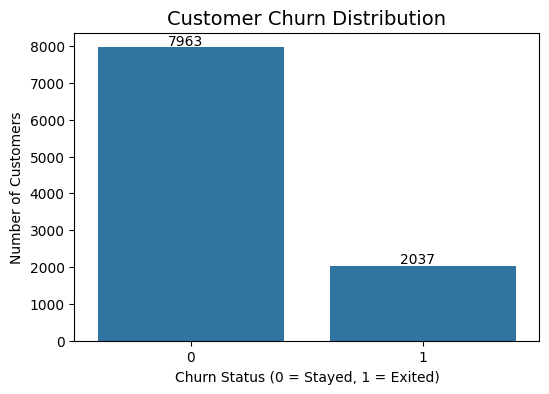

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn Status (0 = Stayed, 1 = Exited)")
plt.ylabel("Number of Customers")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + 0.3, p.get_height() + 50)
    )

plt.show()

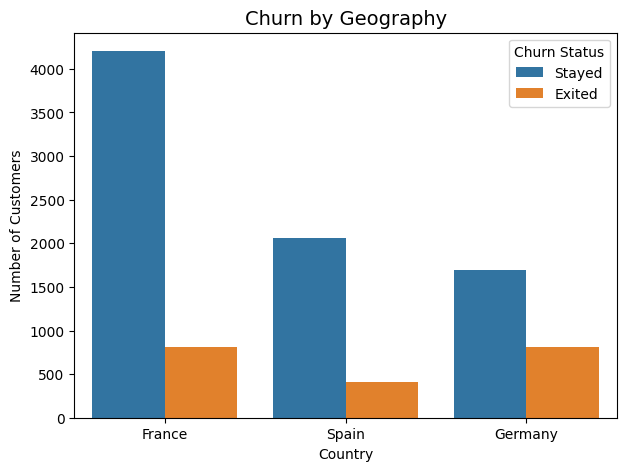

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

plt.title("Churn by Geography", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status", labels=["Stayed", "Exited"])

plt.show()

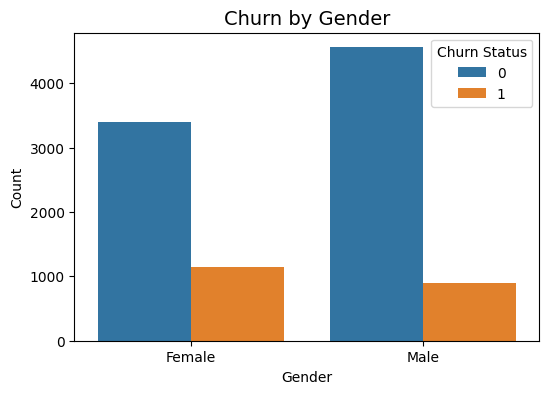

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="Gender",
    hue="Exited",
    data=df
)

plt.title("Churn by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Churn Status")

plt.show()

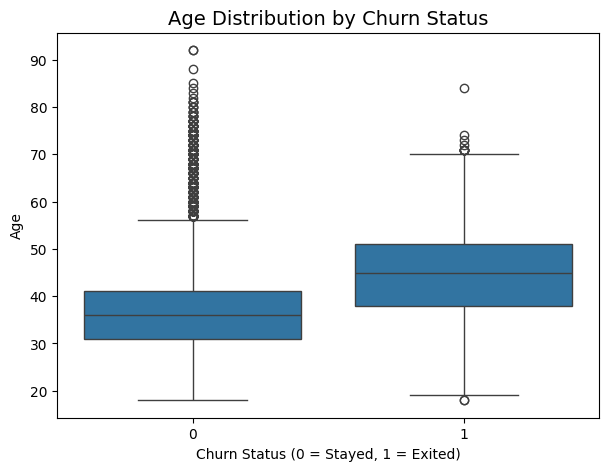

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

plt.title("Age Distribution by Churn Status", fontsize=14)
plt.xlabel("Churn Status (0 = Stayed, 1 = Exited)")
plt.ylabel("Age")

plt.show()

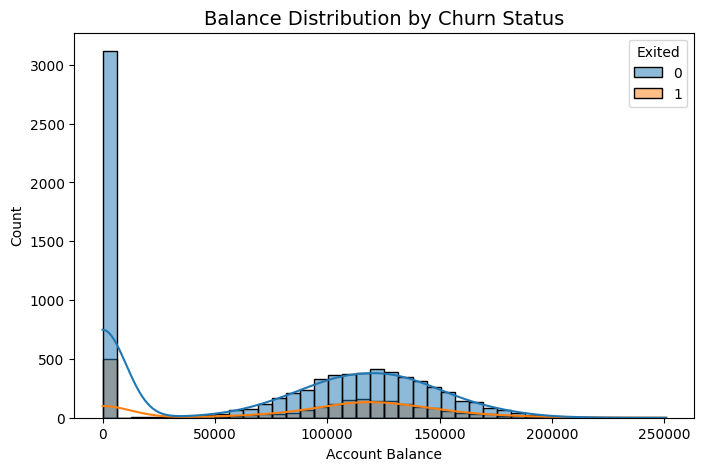

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Balance",
    hue="Exited",
    kde=True,
    bins=40
)

plt.title("Balance Distribution by Churn Status", fontsize=14)
plt.xlabel("Account Balance")
plt.ylabel("Count")

plt.show()

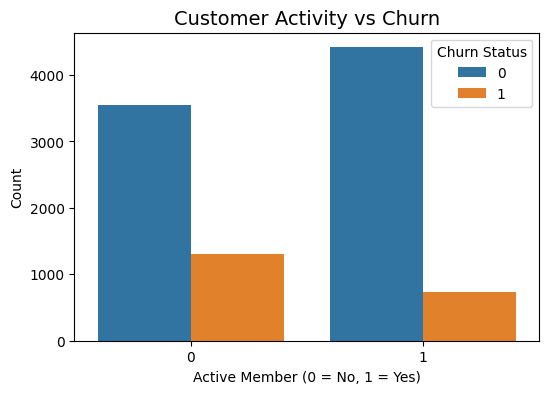

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="IsActiveMember",
    hue="Exited",
    data=df
)

plt.title("Customer Activity vs Churn", fontsize=14)
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.legend(title="Churn Status")

plt.show()

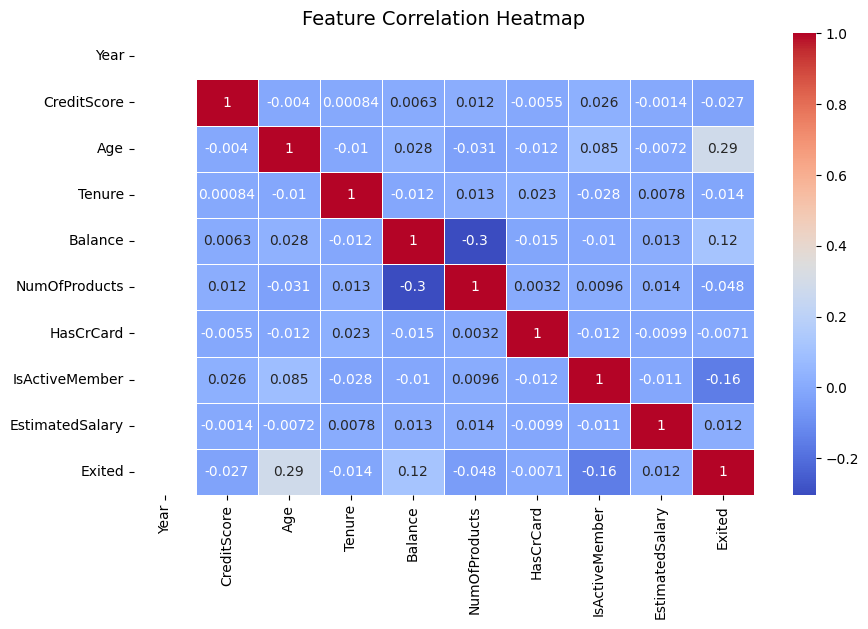

In [ ]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.show()

In [ ]:
churn_rate = df["Exited"].value_counts(normalize=True) * 100
print(churn_rate)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
df["BalanceSalaryRatio"] = (
    df["Balance"] /
    df["EstimatedSalary"]
)


df["ProductDensity"] = (
    df["NumOfProducts"] /
    (df["Tenure"]+1)
)


df["EngagementScore"] = (
    df["HasCrCard"] +
    df["IsActiveMember"]
)


df["AgeTenureInteraction"] = (
    df["Age"] *
    df["Tenure"]
)

In [ ]:
X = df.drop(
    "Exited",
    axis=1
)


y = df["Exited"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
cat_features = [
    "Geography",
    "Gender"
]


num_features = [
    col for col in X.columns
    if col not in cat_features
]

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(
                drop="first"
            ),
            cat_features
        ),


        (
            "num",
            StandardScaler(),
            num_features
        )

    ]

)

In [ ]:
lr = Pipeline([

("prep",preprocessor),

("model",
 LogisticRegression())

])


lr.fit(
    X_train,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model', LogisticRegression())])

In [ ]:
dt = Pipeline([

("prep",preprocessor),

("model",
DecisionTreeClassifier())

])


dt.fit(
X_train,
y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model', DecisionTreeClassifier())])

In [ ]:
rf = Pipeline([

("prep",preprocessor),

("model",
RandomForestClassifier(
n_estimators=200,
random_state=42
))

])


rf.fit(
X_train,
y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
gb = Pipeline([

("prep",preprocessor),

("model",
GradientBoostingClassifier())

])


gb.fit(
X_train,
y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model', GradientBoostingClassifier())])

In [ ]:
models = {

"Logistic Regression":lr,

"Decision Tree":dt,

"Random Forest":rf,

"Gradient Boosting":gb

}

In [ ]:
results=[]


for name,model in models.items():

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]


    results.append({

    "Model":name,

    "Accuracy":
    accuracy_score(y_test,pred),

    "Precision":
    precision_score(y_test,pred),

    "Recall":
    recall_score(y_test,pred),

    "F1":
    f1_score(y_test,pred),

    "ROC-AUC":
    roc_auc_score(y_test,prob)

    })


results_df=pd.DataFrame(results)


results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.809,0.598425,0.186732,0.284644,0.774368
1,Decision Tree,0.783,0.468677,0.496314,0.482100,0.676280
2,Random Forest,0.865,0.777328,0.471744,0.587156,0.854478
3,Gradient Boosting,0.868,0.782609,0.486486,0.600000,0.868050


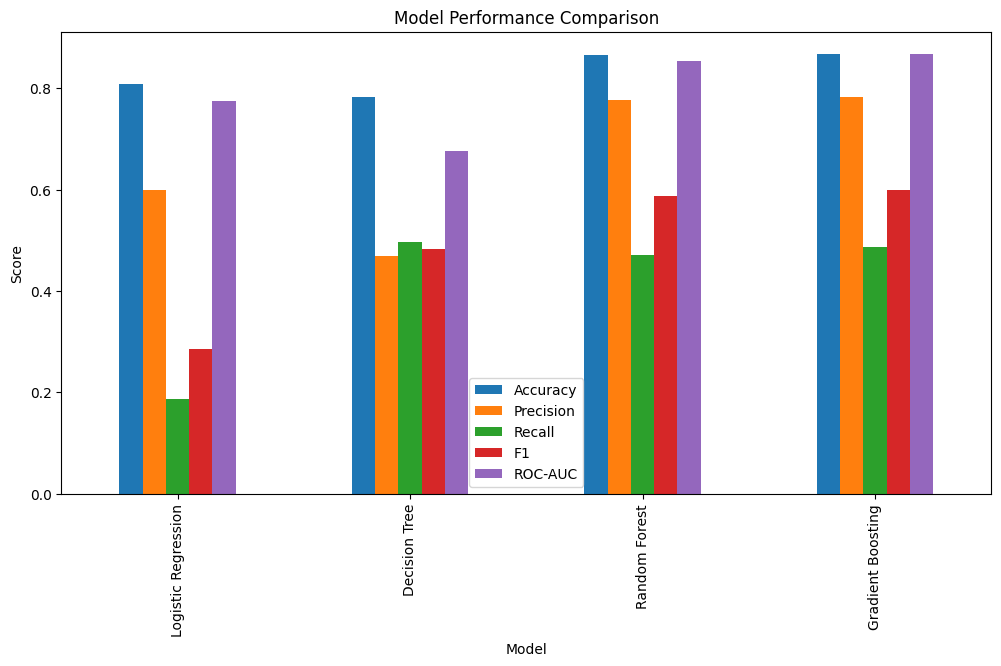

In [ ]:
results_df.set_index(
"Model"
).plot(
kind="bar",
figsize=(12,6)
)


plt.title(
"Model Performance Comparison"
)


plt.ylabel(
"Score"
)


plt.show()

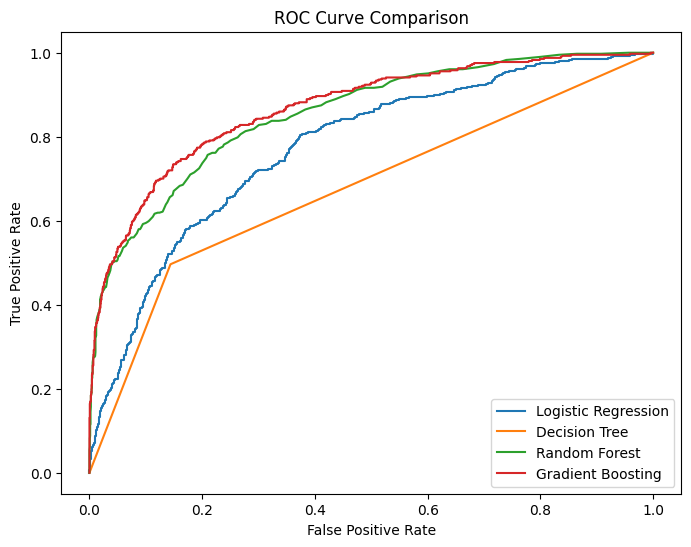

In [ ]:
plt.figure(figsize=(8,6))


for name,model in models.items():

    prob=model.predict_proba(X_test)[:,1]

    fpr,tpr,_=roc_curve(
        y_test,
        prob
    )


    plt.plot(
        fpr,
        tpr,
        label=name
    )


plt.legend()


plt.title(
"ROC Curve Comparison"
)


plt.xlabel(
"False Positive Rate"
)


plt.ylabel(
"True Positive Rate"
)


plt.show()

In [ ]:
rf.named_steps

{'prep': ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first'),
                                  ['Geography', 'Gender']),
                                 ('num', StandardScaler(),
                                  ['Year', 'CreditScore', 'Age', 'Tenure',
                                   'Balance', 'NumOfProducts', 'HasCrCard',
                                   'IsActiveMember', 'EstimatedSalary',
                                   'BalanceSalaryRatio', 'ProductDensity',
                                   'EngagementScore', 'AgeTenureInteraction'])]),
 'model': RandomForestClassifier(n_estimators=200, random_state=42)}

In [ ]:
rf_model = rf.named_steps["model"]

# Get the preprocessing step automatically
transformer_name = list(rf.named_steps.keys())[0]

feature_names = rf.named_steps[transformer_name].get_feature_names_out()


importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})


importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
5,num__Age,0.195035
8,num__NumOfProducts,0.112307
4,num__CreditScore,0.104060
11,num__EstimatedSalary,0.101919
7,num__Balance,0.098207
15,num__AgeTenureInteraction,0.092490
12,num__BalanceSalaryRatio,0.081876
13,num__ProductDensity,0.051353
6,num__Tenure,0.038112
10,num__IsActiveMember,0.032355


In [ ]:
rf

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                   'EngagementScore',
                                                   'AgeTenureInteraction'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

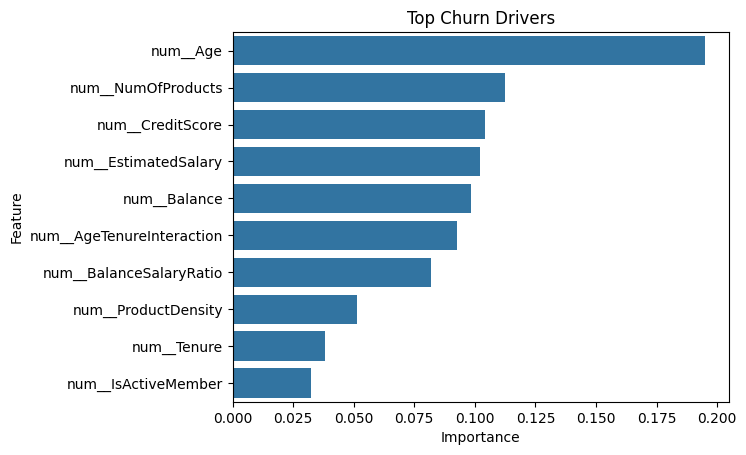

In [ ]:
sns.barplot(
data=importance.sort_values(
"Importance",
ascending=False
).head(10),

x="Importance",

y="Feature"
)


plt.title(
"Top Churn Drivers"
)


plt.show()

In [ ]:
joblib.dump(
    gb,
    "bank_churn_pipeline.pkl"
)

['bank_churn_pipeline.pkl']

In [ ]:
files.download(
"bank_churn_pipeline.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.809,0.598425,0.186732,0.284644,0.774368
1,Decision Tree,0.783,0.468677,0.496314,0.482100,0.676280
2,Random Forest,0.865,0.777328,0.471744,0.587156,0.854478
3,Gradient Boosting,0.868,0.782609,0.486486,0.600000,0.868050


In [ ]:
from google.colab import files

files.download(
    "bank_churn_pipeline.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
%who

ColumnTransformer	 DecisionTreeClassifier	 GradientBoostingClassifier	 LogisticRegression	 OneHotEncoder	 Pipeline	 RandomForestClassifier	 StandardScaler	 X	 
X_test	 X_train	 accuracy_score	 ax	 cat_features	 churn_rate	 classification_report	 confusion_matrix	 corr	 
df	 dt	 f1_score	 feature_names	 files	 fpr	 gb	 importance	 joblib	 
lr	 model	 models	 name	 np	 num_features	 os	 p	 path	 
pd	 plt	 precision_score	 pred	 preprocessor	 prob	 recall_score	 results	 results_df	 
rf	 rf_model	 roc_auc_score	 roc_curve	 sklearn	 sns	 time	 tpr	 train_test_split	 
transformer_name	 uploaded	 warnings	 y	 y_test	 y_train	 


In [ ]:
import joblib

joblib.dump(model, "bank_churn_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.exists("bank_churn_pipeline.pkl"))
print(os.path.abspath("bank_churn_pipeline.pkl"))

True
/content/bank_churn_pipeline.pkl


In [ ]:
from google.colab import files

files.download("bank_churn_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
import joblib

print("scikit-learn:", sklearn.__version__)
print(type(model))

joblib.dump(model, "bank_churn_pipeline.pkl")

scikit-learn: 1.6.1
<class 'sklearn.pipeline.Pipeline'>


['bank_churn_pipeline.pkl']